# 04 - Model Evaluation

- Load the saved models
- Load the test dataset
- Evaluate each model on the test set
- Compare the final results
- Create confusion matrices
- Plot ROC curves
- Review feature importance
- Select the best model

#### Import libraries

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

#### Define RNN Model and Adapter

In [2]:
class ChurnRNN(nn.Module):

    def __init__(self, input_size, hidden_size=32):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            nonlinearity="tanh"
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        _, hidden_state = self.rnn(x)

        final_hidden_state = hidden_state[-1]

        logits = self.output_layer(
            final_hidden_state
        )

        return logits.squeeze(1)

In [3]:
class RNNAdapter:

    def __init__(self, model):
        self.model = model

    def _prepare_data(self, X):

        if isinstance(X, pd.DataFrame):
            values = X.to_numpy(dtype=np.float32)
        else:
            values = np.asarray(
                X,
                dtype=np.float32
            )

        return torch.tensor(
            values
        ).unsqueeze(1)

    def predict_proba(self, X):

        features = self._prepare_data(X)

        self.model.eval()

        with torch.no_grad():

            logits = self.model(features)

            probabilities = torch.sigmoid(
                logits
            ).numpy()

        return np.column_stack([
            1 - probabilities,
            probabilities
        ])

    def predict(self, X):

        probabilities = self.predict_proba(X)[:, 1]

        return (
            probabilities >= 0.5
        ).astype(int)

#### Load the test dataset

In [4]:
test_data = pd.read_csv(
    "../DataSet/processed/telco_churn_test.csv"
)

print("Test data shape:", test_data.shape)

Test data shape: (1055, 47)


#### Preview the test data

In [5]:
test_data.head()

,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_0,SeniorCitizen_1,Churn
0,-0.792793,0.324107,-0.582040,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0
1,0.549528,0.803370,0.857740,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,1.200350,0.702560,1.283487,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
3,-1.158880,0.370381,-0.866260,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1
4,-1.118204,0.960370,-0.792521,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1


#### Separate the features and target

In [6]:
X_test = test_data.drop(columns=["Churn"])
y_test = test_data["Churn"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (1055, 46)
y_test: (1055,)


#### Load the trained models

In [7]:
logistic_model = joblib.load(
    "../models/logistic_regression.joblib"
)

decision_tree_model = joblib.load(
    "../models/decision_tree.joblib"
)

random_forest_model = joblib.load(
    "../models/random_forest.joblib"
)

mlp_model = joblib.load(
    "../models/mlp.joblib"
)

rnn_model = ChurnRNN(
    input_size=X_test.shape[1],
    hidden_size=32
)

rnn_model.load_state_dict(
    torch.load(
        "../models/rnn.pth",
        map_location="cpu",
        weights_only=True
    )
)

rnn_model.eval()

rnn_classifier = RNNAdapter(
    rnn_model
)

print("All trained models loaded.")

All trained models loaded.


#### Create an evaluation function

In [9]:
def evaluate_model(model_name, model, X, y):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions),
        "Recall": recall_score(y, predictions),
        "F1-Score": f1_score(y, predictions),
        "ROC-AUC": roc_auc_score(y, probabilities)
    }

    return results

#### Evaluate all models

In [10]:
logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

decision_tree_results = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_test,
    y_test
)

random_forest_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

mlp_results = evaluate_model(
    "Multi-Layer Perceptron",
    mlp_model,
    X_test,
    y_test
)

rnn_results = evaluate_model(
    "Recurrent Neural Network",
    rnn_classifier,
    X_test,
    y_test
)

rnn_results

{'Model': 'Recurrent Neural Network',
 'Accuracy': 0.7175355450236967,
 'Precision': 0.48034934497816595,
 'Recall': 0.7857142857142857,
 'F1-Score': 0.5962059620596206,
 'ROC-AUC': 0.8257534562211981}

#### Compare the test results

In [13]:
test_results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    mlp_results,
    rnn_results
])

test_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.787678,0.616667,0.528571,0.569231,0.822177
1,Decision Tree,0.776303,0.600000,0.471429,0.528000,0.810970
2,Random Forest,0.779147,0.608295,0.471429,0.531187,0.819217
3,Multi-Layer Perceptron,0.779147,0.613527,0.453571,0.521561,0.821583
4,Recurrent Neural Network,0.717536,0.480349,0.785714,0.596206,0.825753


The models were evaluated on the test dataset using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. These metrics provide a more complete evaluation than accuracy alone because they measure different aspects of classification performance.

#### Sort the models by ROC-AUC

In [14]:
sorted_results = test_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

sorted_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Recurrent Neural Network,0.717536,0.480349,0.785714,0.596206,0.825753
1,Logistic Regression,0.787678,0.616667,0.528571,0.569231,0.822177
2,Multi-Layer Perceptron,0.779147,0.613527,0.453571,0.521561,0.821583
3,Random Forest,0.779147,0.608295,0.471429,0.531187,0.819217
4,Decision Tree,0.776303,0.600000,0.471429,0.528000,0.810970


#### Save the test results

In [15]:
test_results.to_csv(
    "../models/test_results.csv",
    index=False
)

print("Test results were saved.")

Test results were saved.


#### Display classification reports

In [16]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Multi-Layer Perceptron": mlp_model,
    "Recurrent Neural Network": rnn_classifier

}

for model_name, model in models.items():
    predictions = model.predict(X_test)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_test, predictions))

Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       775
           1       0.62      0.53      0.57       280

    accuracy                           0.79      1055
   macro avg       0.73      0.70      0.71      1055
weighted avg       0.78      0.79      0.78      1055

Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       775
           1       0.60      0.47      0.53       280

    accuracy                           0.78      1055
   macro avg       0.71      0.68      0.69      1055
weighted avg       0.76      0.78      0.77      1055

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       775
           1       0.61      0.47      0.53       280

    accuracy                           0.78      1055
   macro avg       0.72      0.68      0.69      1055
weighted avg       0.77   

#### Create confusion matrices

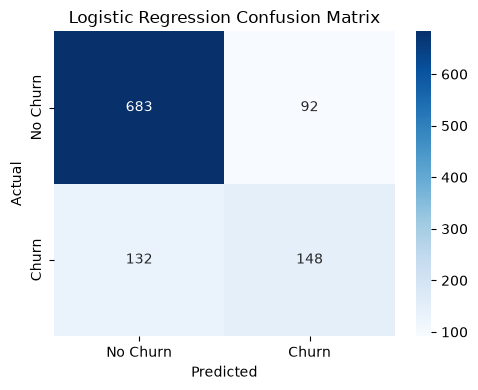

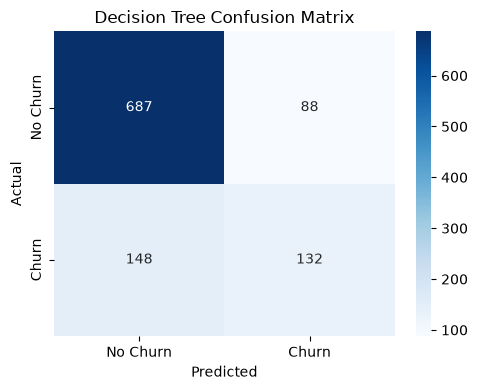

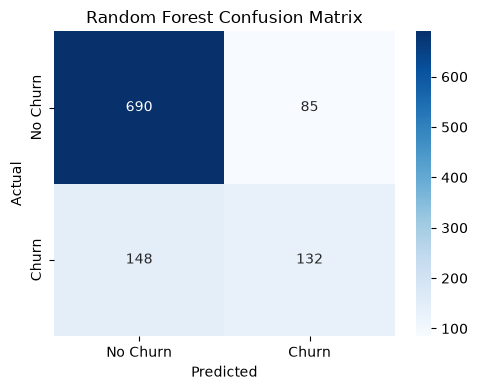

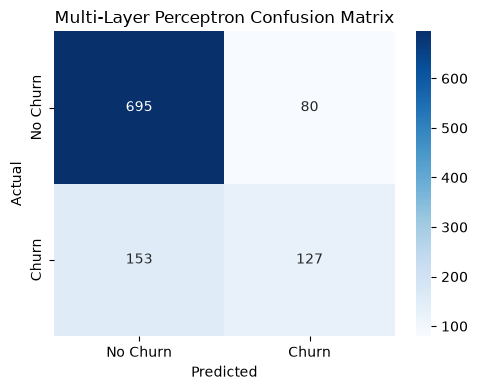

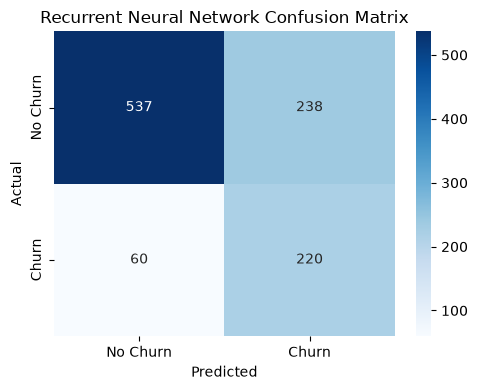

In [17]:
for model_name, model in models.items():
    predictions = model.predict(X_test)
    matrix = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

The confusion matrices show how many customers were classified correctly and incorrectly.

The values on the diagonal represent correct predictions, while the off-diagonal values represent prediction errors. A better model correctly identifies both customers who churn and customers who stay with the company.

#### Plot ROC curves

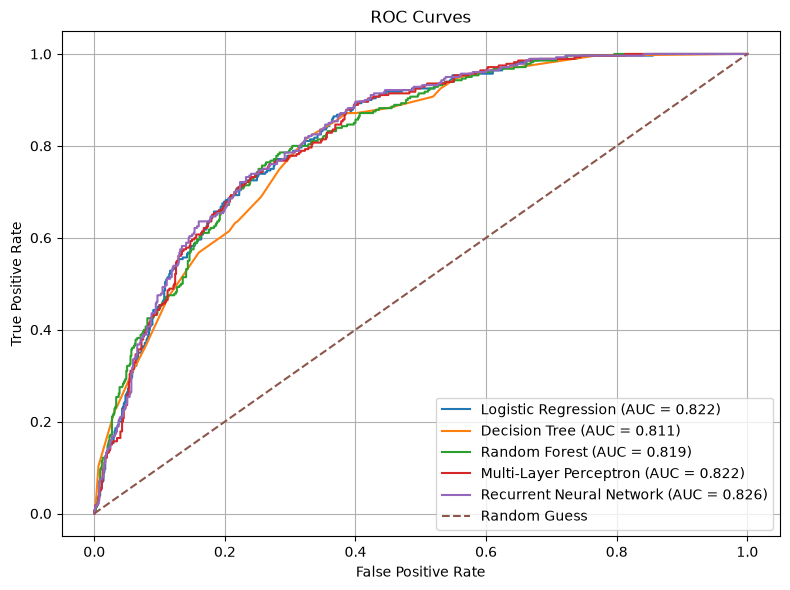

In [18]:
plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The ROC curves compare how well each model separates churn and non-churn customers. A higher ROC-AUC score indicates better overall classification performance.

#### Compare model performance

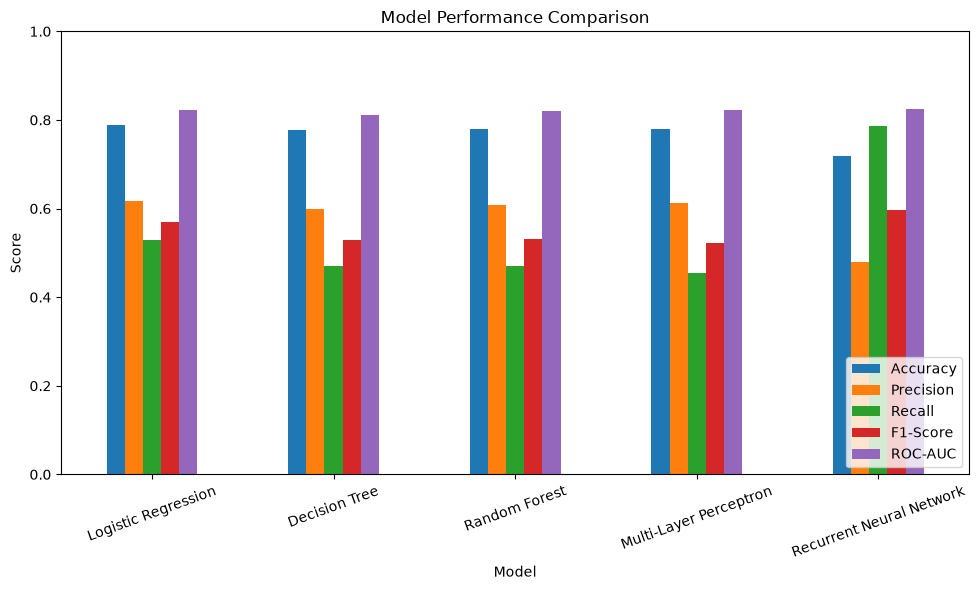

In [20]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

test_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Random Forest feature importance

In [21]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,tenure,0.143732
2,TotalCharges,0.128301
1,MonthlyCharges,0.094015
35,Contract_Month-to-month,0.087638
17,OnlineSecurity_No,0.044908
26,TechSupport_No,0.038328
42,PaymentMethod_Electronic check,0.037788
15,InternetService_Fiber optic,0.037694
37,Contract_Two year,0.031462
20,OnlineBackup_No,0.021231


#### Plot the most important features

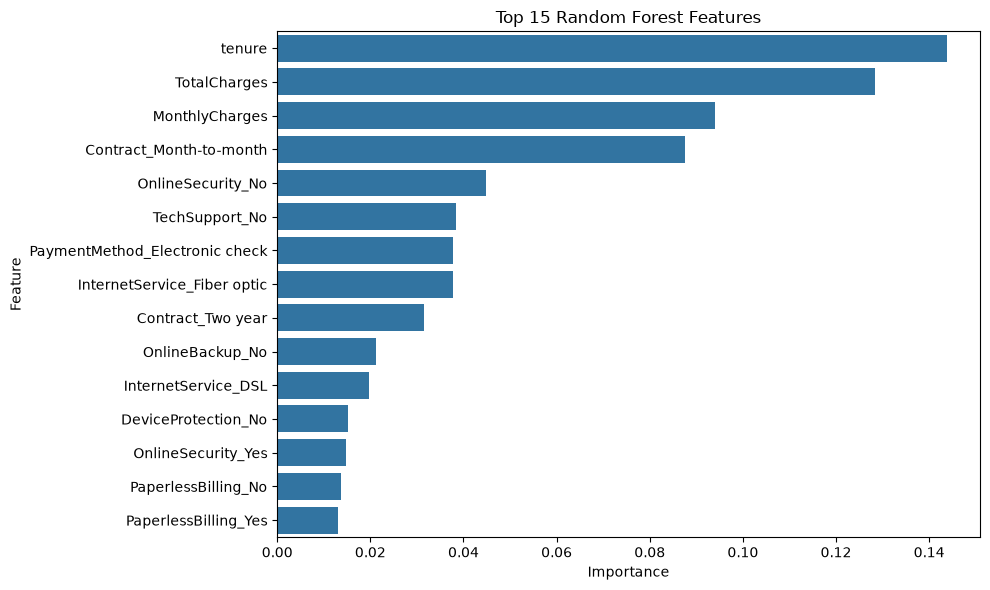

In [22]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Some customers were still classified incorrectly because their characteristics were similar to both churn and non-churn groups. Customers with similar tenure, monthly charges, or service plans can be more difficult for the models to classify correctly. Even with these challenges, the selected model produced strong overall performance on the test dataset.

#### Compare the Best Model for Each Evaluation Metric

In [23]:
evaluation_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]
metric_results = test_results.set_index("Model")[metrics]

pd.DataFrame({
    "Best Model": metric_results.idxmax(),
    "Score": metric_results.max().round(4)
})

,Best Model,Score
Accuracy,Logistic Regression,0.7877
Precision,Logistic Regression,0.6167
Recall,Recurrent Neural Network,0.7857
F1-Score,Recurrent Neural Network,0.5962
ROC-AUC,Recurrent Neural Network,0.8258


#### Model Performance Trade-Off

No single model performed best across every evaluation metric.

Logistic Regression achieved the highest accuracy and precision, making it the stronger choice when balanced performance and fewer false-positive churn predictions are important.

The Recurrent Neural Network achieved the highest recall, F1-score, and ROC-AUC. Its class-weighted loss caused it to identify more customers who churned, but this also lowered its precision and overall accuracy.

Therefore, Logistic Regression provides the stronger general-purpose baseline, while the Recurrent Neural Network may be preferred when identifying as many potential churn customers as possible is the main priority.

## Summary

This project explored customer churn prediction using four machine learning models.

The data was explored, cleaned, preprocessed, and divided into training, validation, and test datasets. Logistic Regression, Decision Tree, Random Forest, and Multi-Layer Perceptron models were trained and evaluated using multiple performance metrics.

Based on the evaluation results, Logistic Regression achieved the best overall performance and was selected as the final model for predicting customer churn. This project shows how machine learning can help telecommunication companies identify customers who are more likely to leave and support customer retention strategies.